# [알고리즘].  알고리즘의 기초 연결리스트 편
---

>📌 본 포스팅은  연결리스트 알고리즘에 대한 내용을 다룹니다.
📌 [참고]
---
- 
## **<span style="color:brown"> 1. 연결리스트와 어레이 . </span>**
- 리스트와 linked list 의 성능 : 값을 꺼내기가 쉽냐, 넣기가 쉽냐, 지우기가 쉽냐로 판단
- 조회관점에서는 리스트가 훨씬 좋다. array[3] 하면 조회가 O(1) 로 끝. linked list는 처음부터 살펴야하기때문에 최악의 경우 처음부터 하나씩 조회하면서 목표 메모리까지 도달 = O(n)
- 리스트는 삽입할때 싹다 한칸씩 옴기고 4번째 메모리에 데이터를 넣어야함. 
- 연결리스트는 상자가 다음 상자를 가리키게 만드는 구조라서 가리키는 위치만 바꾸면 됨 삽입에 특화됨. 


| case           | Array                                                                         | LinkedList                                                   |
|----------------|-------------------------------------------------------------------------------|--------------------------------------------------------------|
| Read           | O(1)                                                                          | O(N)                                                         |
| Insert, Delete | O(N)                                                                          | O(1)                                                         |
| Append         | 꽉차면 새 메모리 할당 |  노드 끝 동적 추가 |
| 결론         | 접근 ->Array                          | 삽입 삭제 -> LinkedList |



## **<span style="color:brown"> 2. LinkedList 구현 </span>**

```Python

class ListNode: 
    
    def __init__(self, val = 0, next = None):
        self.val = val
        self.next = next
        F.b(f"   - ⭐️ ListNode({val})실행  : [결과 ({self.val}, {self.next})]")
    def __str__(self):
        return f"({self.val}, {self.next})"

class LinkedList:
    def __init__(self):
        self.head = None
        F.g(f"⭐️ LinkedList() 실행 [head : {self.head}]")
        
    def append(self,val):
        F.r(f"\n 👉LinkedList.append({val}) 실행 : LinkedList 끝 노드에 {val}을 추가합니다.")
        if not self.head:
            F.y(f"   - 기존 헤드 값 {self.head}. =>  head에  {val} 삽입.")
            self.head = ListNode(val,None)
            # print(f"\t self.head:({self.head.val} , {self.head.next})")
            return 

        node = self.head
        F.y(f"    :: 현재 LinkedList 상태 {node} ::")
        step = 0
        F.g(f"       •STEP({step})-> node.next 없음" if not node.next else "  🔸 insert 위해 끝 node 가기 START")
        while node.next:
            if  node.next:
                F.g(f"      •STEP({step})-> node.next 값{node.next} ")
            node = node.next
            step +=1
        F.y(f"   - 끝노드[{node.val},{node.next}]도착!! 다음 노드에 {val} 추가한 결과↓↓↓↓")
        node.next = ListNode(val,None)
        
        ## print(ln) 연결 구조 시각화
        result = []
        node = self.head
        while node:
          result.append(str(node.val))
          node = node.next
        F.y(f"     ::APPEND 후 최종 LinkedList 상태 { ' -> '.join(result)}")
    
    def __str__(self):
        ## print(ln) 연결 구조 시각화
        result = []
        node = self.head
        while node:
          result.append(str(node.val))
          node = node.next
        return " -> ".join(result)
    
ln =LinkedList()

ln.append(3)
ln.append(5)
ln.append(7)
ln.append(9)

```

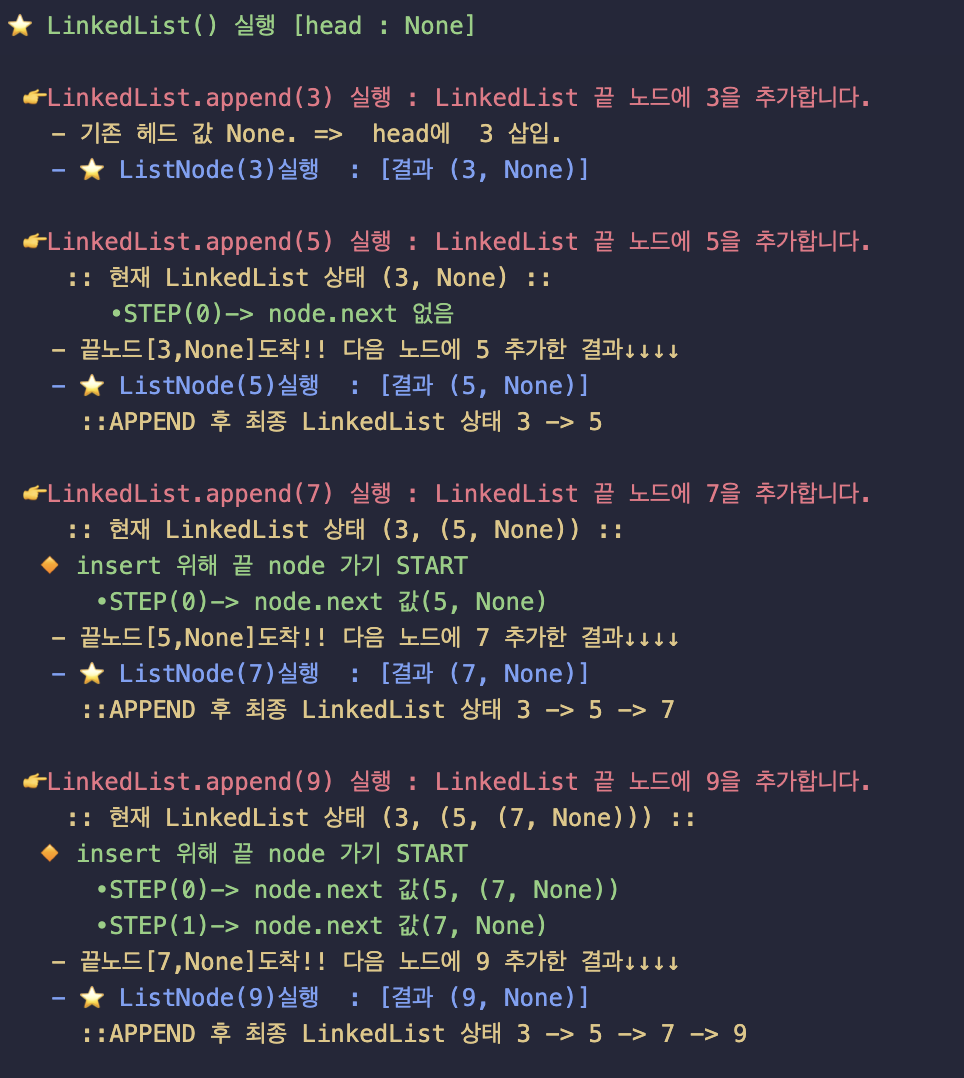

- 상자와 화살표를 합쳐서 노드라고 함. 
- 노드를 이용해 연결된 녀석. 
- 내가가진값 : val
- 상자가 연결하는 화살표 : next
- 값이 안들어올 경우 기본값 0 : val =0 
- 화살표 없을경우 next = None
- 첫 요소를 알아야 마지막까지 조회가능 : head = None
- 만약 head 가 아무것도 없으면 하나 만들어줘야한다. 
- 제일 헤드에서 테일까지 간다음에 마지막에 붙여준다. 
- 노드 = 헤드 
- 다음요소가 있으면 계속 노드를 교체한다. 
- 마지막 노드에 오면 while 끝나고 다음 노드를 만들어 지목해준다. 

---

# [알고리즘]. 연결리스트로 구현한 펠린드롬
---
<br>
📌 본 포스팅은  **연결리스트로 구현한 펠린드롬** 에 대한 내용을 다룹니다. <br>
📌 [참고] <br>

---


## **<span style="color:brown"> 1.연결리스트 펠린드롬  </span>**
⓵ 연결리스트를 사용하지 않았을 때            <br>
```Python
import sys 
a = sys.stdin.readline().rstrip()
reverse_a="".join(list(reversed(a)))
print(True if a==reverse_a else False)
```

⓶ 연결리스트 를 사용하여 펠린드롬인지 확인 할때             <br>


```Python
def isPalindrome(ln):
    from structures import F
    F.b("\n펠린드롬 인지 확인합니다")
    arr = []
    head = ln.head
    print(f"head :{head} ")

    if not head:
        print("아무 것도 없으므로 펠린드롬입니다")
        return True

    node = head
    F.b("LL 순회하며 원소를 리스트에 저장")
    while node:
        arr.append(node.val)
        node = node.next
        print(arr,node)
    
    F.b("리스트 양끝 pop 하면서 비교")
    while len(arr) > 1:
        first = arr.pop(0)
        last = arr.pop()
        F.y(f"? First {first} == Last {last}")
        if first != last:
            F.r(f"First {first} != Last {last} 다름")
            return False

    return True

assert isPalindrome(ln)
```

### <span style="background-color:#fff5b1"> <span style="color:blue"> 🫡 실행결과</span> </span>
![Screenshot 2024-12-19 at 8.53.39 PM.png](<attachment:Screenshot 2024-12-19 at 8.53.39 PM.png>)


##### <span style="color:orange"> **✅ [결론]**<br> **[⭐️] 알고리즘 공부할때는 파이썬 내장함수도 모조리 직접구현해서 문제를 풀도록 하자!** 


</span>


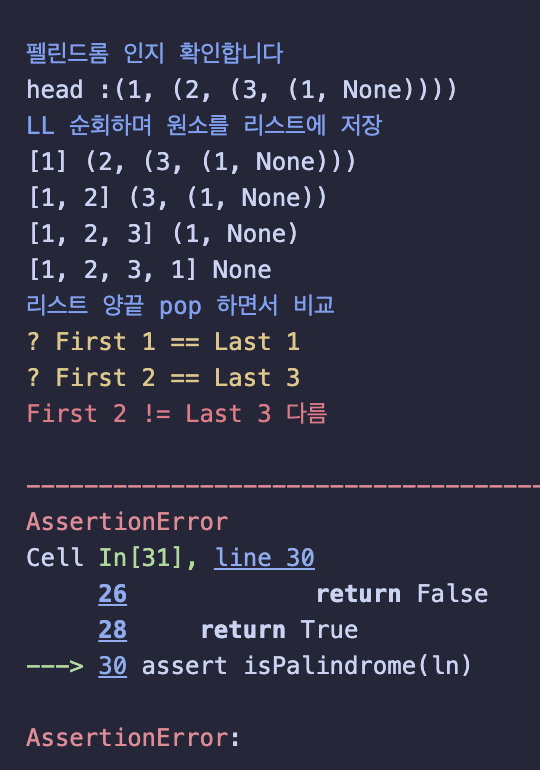

In [7]:
class F:
    ### Functions ### 
    # 기본 세팅
    def colored_text(text, color='default', bold=False):
            '''
            #### 예시 사용법
            print(colored_text('저장 하지 않습니다.', 'red'))
            print(colored_text('저장 합니다.', 'green'))
            default,red,green,yellow,blue, magenta, cyan, white, rest
            '''
            colors = {
                'default': '\033[99m',
                'red': '\033[91m',
                'green': '\033[92m',
                'yellow': '\033[93m',
                'blue': '\033[94m',
                'magenta': '\033[95m', #보라색
                'cyan': '\033[96m',
                'white': '\033[97m',
                'bright_black': '\033[90m',  # 밝은 검정색 (회색)
                'bright_red': '\033[91m',  # 밝은 빨간색
                'bright_green': '\033[92m',  # 밝은 초록색
                'bright_yellow': '\033[93m',  # 밝은 노란색
                'bright_blue': '\033[94m',  # 밝은 파란색
                'bright_magenta': '\033[95m',  # 밝은 보라색
                'bright_cyan': '\033[96m',  # 밝은 청록색
                'bright_white': '\033[97m',  # 밝은 흰색
                'reset': '\033[0m'
            }
            color_code = colors.get(color, colors['default'])
            bold_code = '\033[1m' if bold else ''
            reset_code = colors['reset']
            
            return f"{bold_code}{color_code}{text}{reset_code}"
    def b(str):print( F.colored_text(str,'blue'))
    def y(str):print( F.colored_text(str,'yellow'))
    def r(str):print( F.colored_text(str,'red'))
    def g(str):print( F.colored_text(str,'green'))


In [8]:
class ListNode: 
    
    def __init__(self, val = 0, next = None):
        self.val = val
        self.next = next
        F.b(f"   - ⭐️ ListNode({val})실행  : [결과 ({self.val}, {self.next})]")
    def __str__(self):
        return f"({self.val}, {self.next})"

class LinkedList:
    def __init__(self):
        self.head = None
        F.g(f"⭐️ LinkedList() 실행 [head : {self.head}]")
        
    def append(self,val):
        F.r(f"\n 👉LinkedList.append({val}) 실행 : LinkedList 끝 노드에 {val}을 추가합니다.")
        if not self.head:
            F.y(f"   - 기존 헤드 값 {self.head}. =>  head에  {val} 삽입.")
            self.head = ListNode(val,None)
            # print(f"\t self.head:({self.head.val} , {self.head.next})")
            return 

        node = self.head
        F.y(f"    :: 현재 LinkedList 상태 {node} ::")
        step = 0
        F.g(f"       •STEP({step})-> node.next 없음" if not node.next else "  🔸 insert 위해 끝 node 가기 START")
        while node.next:
            if  node.next:
                F.g(f"      •STEP({step})-> node.next 값{node.next} ")
            node = node.next
            step +=1
        F.y(f"   - 끝노드[{node.val},{node.next}]도착!! 다음 노드에 {val} 추가한 결과↓↓↓↓")
        node.next = ListNode(val,None)
        
        ## print(ln) 연결 구조 시각화
        result = []
        node = self.head
        while node:
          result.append(str(node.val))
          node = node.next
        F.y(f"     ::APPEND 후 최종 LinkedList 상태 { ' -> '.join(result)}")
    
    def __str__(self):
        ## print(ln) 연결 구조 시각화
        result = []
        node = self.head
        while node:
          result.append(str(node.val))
          node = node.next
        return " -> ".join(result)
    
ln =LinkedList()

ln.append(3)
ln.append(5)
ln.append(7)
ln.append(9)



⭐️ LinkedList() 실행 [head : None]

 👉LinkedList.append(3) 실행 : LinkedList 끝 노드에 3을 추가합니다.
   - 기존 헤드 값 None. =>  head에  3 삽입.
   - ⭐️ ListNode(3)실행  : [결과 (3, None)]

 👉LinkedList.append(5) 실행 : LinkedList 끝 노드에 5을 추가합니다.
    :: 현재 LinkedList 상태 (3, None) ::
       •STEP(0)-> node.next 없음
   - 끝노드[3,None]도착!! 다음 노드에 5 추가한 결과↓↓↓↓
   - ⭐️ ListNode(5)실행  : [결과 (5, None)]
     ::APPEND 후 최종 LinkedList 상태 3 -> 5

 👉LinkedList.append(7) 실행 : LinkedList 끝 노드에 7을 추가합니다.
    :: 현재 LinkedList 상태 (3, (5, None)) ::
  🔸 insert 위해 끝 node 가기 START
      •STEP(0)-> node.next 값(5, None) 
   - 끝노드[5,None]도착!! 다음 노드에 7 추가한 결과↓↓↓↓
   - ⭐️ ListNode(7)실행  : [결과 (7, None)]
     ::APPEND 후 최종 LinkedList 상태 3 -> 5 -> 7

 👉LinkedList.append(9) 실행 : LinkedList 끝 노드에 9을 추가합니다.
    :: 현재 LinkedList 상태 (3, (5, (7, None))) ::
  🔸 insert 위해 끝 node 가기 START
      •STEP(0)-> node.next 값(5, (7, None)) 
      •STEP(1)-> node.next 값(7, None) 
   - 끝노드[7,None]도착!! 다음 노드에 9 추가한 결과↓↓↓↓
   - ⭐️ ListNode(9)실행  : [결과 (9, None)]


# 펠린드롬 

In [9]:
from structures import LinkedList
ln = LinkedList()
for i in [1,2,3,1]:
    ln.append(i)

⭐️ LinkedList() 실행 [head : None]

 👉LinkedList.append(1) 실행 : LinkedList 끝 노드에 1을 추가합니다.
   - 기존 헤드 값 None. =>  head에  1 삽입.
   - ⭐️ ListNode(1)실행  : [결과 (1, None)]

 👉LinkedList.append(2) 실행 : LinkedList 끝 노드에 2을 추가합니다.
    :: 현재 LinkedList 상태 (1, None) ::
       •STEP(0)-> node.next 없음
   - 끝노드[1,None]도착!! 다음 노드에 2 추가한 결과↓↓↓↓
   - ⭐️ ListNode(2)실행  : [결과 (2, None)]
     ::APPEND 후 최종 LinkedList 상태 1 -> 2

 👉LinkedList.append(3) 실행 : LinkedList 끝 노드에 3을 추가합니다.
    :: 현재 LinkedList 상태 (1, (2, None)) ::
  🔸 insert 위해 끝 node 가기 START
      •STEP(0)-> node.next 값(2, None) 
   - 끝노드[2,None]도착!! 다음 노드에 3 추가한 결과↓↓↓↓
   - ⭐️ ListNode(3)실행  : [결과 (3, None)]
     ::APPEND 후 최종 LinkedList 상태 1 -> 2 -> 3

 👉LinkedList.append(1) 실행 : LinkedList 끝 노드에 1을 추가합니다.
    :: 현재 LinkedList 상태 (1, (2, (3, None))) ::
  🔸 insert 위해 끝 node 가기 START
      •STEP(0)-> node.next 값(2, (3, None)) 
      •STEP(1)-> node.next 값(3, None) 
   - 끝노드[3,None]도착!! 다음 노드에 1 추가한 결과↓↓↓↓
   - ⭐️ ListNode(1)실행  : [결과 (1, None)]


In [10]:
def isPalindrome(ln):
    from structures import F
    F.b("\n펠린드롬 인지 확인합니다")
    arr = []
    head = ln.head
    print(f"head :{head} ")

    if not head:
        print("아무 것도 없으므로 펠린드롬입니다")
        return True

    node = head
    F.b("LL 순회하며 원소를 리스트에 저장")
    while node:
        arr.append(node.val)
        node = node.next
        print(arr,node)
    
    F.b("리스트 양끝 pop 하면서 비교")
    while len(arr) > 1:
        first = arr.pop(0)
        last = arr.pop()
        F.y(f"? First {first} == Last {last}")
        if first != last:
            F.r(f"First {first} != Last {last} 다름")
            return False

    return True

assert isPalindrome(ln)


펠린드롬 인지 확인합니다
head :(1, (2, (3, (1, None)))) 
LL 순회하며 원소를 리스트에 저장
[1] (2, (3, (1, None)))
[1, 2] (3, (1, None))
[1, 2, 3] (1, None)
[1, 2, 3, 1] None
리스트 양끝 pop 하면서 비교
? First 1 == Last 1
? First 2 == Last 3
First 2 != Last 3 다름


AssertionError: 

# 스택 

In [32]:
class Node:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next


class Stack:
    def __init__(self):
        self.top = None

    def push(self, value):
        self.top = Node(value, self.top)

    def pop(self):
        if self.top is None:
            return None

        node = self.top
        self.top = self.top.next

        return node.val

    def is_empty(self):
        return self.top is None
def test_stack():
    stack = Stack()

    stack.push(1)
    stack.push(2)
    stack.push(3)
    stack.push(4)
    stack.push(5)

    assert stack.pop() == 5
    assert stack.pop() == 4
    assert stack.pop() == 3
    assert stack.pop() == 2
    assert stack.pop() == 1
    assert stack.pop() is None
    assert stack.is_empty()

## stack 을 구현하는 법. 
- 연결리스트를 사용하면 된다. 
- 

In [55]:
from structures import F
class Node:
    def __init__(self,val=0,next=None):
        
        self.val = val
        self.next = next
        F.b(f" node 생성 ({self.val},{self.next})")



class Stack:
    def __init__(self):
        self.top =None
        F.b(f" Stack 생성 top :{self.top}")
    def push(self,val):
        # 상자를 만들고 새로운 top 이 된다 
        node = Node(val,None) ## 새로운 노드를 만들어논다. 가리키는게 없는 상태
        node.next = self.top ## 기존의 탑에 화살표를 연결 해준다. 
        ## 하지만 여전히 top 은 기존의 top 을 가리키고 있으므로 새로 들어온놈을 탑으로 설정해준다. 
        self.top = node
        result = [] 
        while node:
            result.append(str(node.val))
            node = node.next
        F.g(" -> ".join(result))  
        
        
    def pop(self):
        pass


### test code 
def test():
    stack = Stack()
    ## push test
    for i in range(1,10):
        stack.push(i)
    ## pop test
    # assert stack.pop() == 9
    
    for i in range(9,0,-1):
        assert stack.pop() == i
    ## is empty test
    assert stack.is_empty()
    
test()

 Stack 생성 top :None
 node 생성 (1,None)
1
 node 생성 (2,None)
2 -> 1
 node 생성 (3,None)
3 -> 2 -> 1
 node 생성 (4,None)
4 -> 3 -> 2 -> 1
 node 생성 (5,None)
5 -> 4 -> 3 -> 2 -> 1
 node 생성 (6,None)
6 -> 5 -> 4 -> 3 -> 2 -> 1
 node 생성 (7,None)
7 -> 6 -> 5 -> 4 -> 3 -> 2 -> 1
 node 생성 (8,None)
8 -> 7 -> 6 -> 5 -> 4 -> 3 -> 2 -> 1
 node 생성 (9,None)
9 -> 8 -> 7 -> 6 -> 5 -> 4 -> 3 -> 2 -> 1


AssertionError: 

>2024.12.28 

- stack 구현 
- 스택 문제 풀기 
- 유효한 괄호 test.py, prac.py

소괄호 중괄호 대괄호 -> 대괄호 중괄호 소괄호 순서로 닫아야함 
-> 스택을 쓰면 좋겠다. 
- 괄호 여는게 먼저다. 닫는게 나오면 스택 제일 위에 있는걸 꺼내와서 닫는거랑 짝이 맞는지 확인한다. 

In [ ]:
## STACK 문제 
def test_problem_stack(s):
    pair = {
        '}': '{',
        ')': '(',
        ']': '[',
    }
    opener = "({["
    stack = []

    for char in s:
        if char in opener:
            stack.append(char)
        else:
            if not stack:
                return False
            top = stack.pop()
            if pair[char] != top:
                return False

    return not stack



## 상식에 맞는 괄호가 부합하는지 다양한 경우의 수에 대한 테스트 
## 정상
assert test_problem_stack("()")
assert test_problem_stack("()[]{}")
assert test_problem_stack("({[][]})")
assert test_problem_stack("({[]})")

## 비정상 
assert not test_problem_stack("(]")
assert not test_problem_stack("(()]")
assert not test_problem_stack("(((])")
assert not test_problem_stack("((())")


In [17]:
## Que 개념 
def test_queue():
    from structures import Queue
    queue = Queue()
    queue.push(1)
    queue.push(2)
    queue.push(3)
    queue.push(4)
    queue.push(5)

    assert queue.pop() == 1
    assert queue.pop() == 2
    assert queue.pop() == 3
    assert queue.pop() == 4
    assert queue.pop() == 5
    assert queue.pop() is None
    assert queue.is_empty()
test_queue()

## Que 문제 풀어보기 
1부터 N까지 차례대로 줄을 섰을 때, <u>맨 앞에 선 사람만 들여보내주고</u> 그 다음 순서인 사람은 제일 뒤로 보내는 특이한 줄서기가 있습니다.
예를 들어 N=6인 경우, 123456 이 순서대로 줄을 서있을 것입니다. 이때 제일 먼저 1이 입장하고 남은 순서는 23456이 됩니다. 2는 두 번째 순서이므로 제일 뒤로 보내서 34562가 됩니다. 다시 3이 입장하여 4562가 되고, 4가 두 번째 순서이므로 5624가 됩니다. 5가 입장하고 246, 2가 입장하고 64, 6이 입장하여 4, 마지막으로 4가 입장하게 됩니다.
N이 주어질 때 제일 마지막으로 입장하는 숫자를 계산하는 프로그램을 작성하세요.

## deque 사용 법 
- Add left : 
    - extendleft()
    - appendleft()
- Remove from left:
    - popleft()
- Add to right :
    - extend()
    - append()
- Remove from right :
    - pop()

NameError: name 'test_problem_queue' is not defined

In [25]:

from collections import deque


def test_problem_queue(num):
    ## Deque 구조 Q로도 사용할수도 stack으로 사용할수도 있는 내장 자료구조
    deq = deque([i for i in range(1, num + 1)])
    
    ## 규칙의 반복 
    ## 1. 앞에있는 놈을 꺼낸다. 
    ## 2. 다음에 잇는 놈도 꺼낸다음 append 
    ## 3. deq 에 남는게 없을때까지 반복 
    while len(deq) > 1:
        deq.popleft()
        deq.append(deq.popleft())
    return deq.popleft()



assert test_problem_queue(2) == 2
assert test_problem_queue(3) == 2
assert test_problem_queue(4) == 4
assert test_problem_queue(5) == 2
assert test_problem_queue(6) == 4
assert test_problem_queue(7) == 6

In [23]:
from collections import deque
deq = deque([i for i in range(1, 10 + 1)])
deq

deque([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# [알고리즘] 제목
---
<br>
📌 요약 <br>
📌 [참고] <br>

---

<!-- Definition-->

# <span style="color:orange"> 🤔 해시테이블이란 란?</span>


>📌 <span style="color:blue"> **해시테이블은**</span> 는 <span style="color:red">
**키 벨류 매핑 자료구조**
</span> 이다.

<!-- image -->
[##_Image|kage@BGdtM/btsLABNLU1c/VUCKDVK8NVUFs4VBzyg5Xk/img.png|CDM|1.3|{"originWidth":1200,"originHeight":876,"style":"alignCenter","width":442,"height":323}_##]


# <span style="color:orange"> 🤔 해시 함수 란?</span>
>📌 <span style="color:blue">**해시함수는**</span> 는 <span style="color:red">
**아웃풋이 범주내 임의의 수인 함수**
</span> 이다.

<!-- image2 -->
[##_Image|kage@bwVrQi/btsLyVTXViO/lhCAOoOKmPObBP28tM8Az0/img.png|CDM|1.3|{"originWidth":1071,"originHeight":647,"style":"alignCenter","width":509,"height":307}_##]




- 임의 의 값을 넣어도 예상 크기 내에 결과가 나오는 함수 
- 길이, 범위고정 값이 예상 범위 내에 값이 나옴. 
- 예 : 나머지를 반환하는 함수 
임의 값을 넣으면 해시함수의 결과가 예측가능 범위에 있다. 
충돌 가능함. 
충돌 해결 법 

해시테이블의 구현 방식 
1. 오픈어드레싱 
같은 해싱값을 갖는 경우 충돌이 일어난다. 
해싱 값이 같을 경우 빈공간을 찾아 나선다. 873 이 차있으면 874에 저장한다. 
탐색 속도가 매우 빠름. 시간 복잡도 O(1)
-
2. 체이닝 
둘다 1일때 15 저장후 그다음 연결리스트를 상요해서 뒤에 값으 ㄹ붙임
메모리를 많이쓰고 길어지면 탐색이 느려짐 O(2)

파이썬 루비, 오픈 어드레싱
c++, java  체이닝 사용


3. 체이닝 구현 

In [ ]:
## 체이닝 방식 해시테이블 
# 모듈러(나머지) 연산 방식 (공간제약)10 으로 나누어 나머지가 결과가 됨. 
#
class HashNode:
    def __init__(self, key=None, value=None):
        self.key = key
        self.value = value
        self.next = None


class HashTable:
    def __init__(self):
        self.size = 10
        self.table = [None] * self.size

    def _hash_function(self, key):
        return key % self.size

    def put(self, key, value):
        index = self._hash_function(key)
        if self.table[index] is None:
            self.table[index] = HashNode(key, value)
        else:
            node = self.table[index]
            while node.next is not None:
                node = node.next
            node.next = HashNode(key, value)

    def get(self, key):
        index = self._hash_function(key)
        node = self.table[index]
        while node is not None:
            if node.key == key:
                return node.value
            node = node.next
        return -1

    def remove(self, key):
        index = self._hash_function(key)
        node = self.table[index]
        prev_node = None
        while node is not None:
            if node.key == key:
                if prev_node is None:
                    self.table[index] = node.next
                else:
                    prev_node.next = node.next
                return
            prev_node = node
            node = node.next



## hash 테이블 테스트 
ht = HashTable()

## 1이라는 키로 1이라는 벨류 저장 
ht.put(1, 1)
## 2이라는 키로 2이라는 벨류 저장 
ht.put(2, 2)

## k-v test
assert ht.get(1) == 1
assert ht.get(2) == 2

## 저장하지 않은 키는 -1 을 리턴
assert ht.get(3) == -1

## 12,22,32 put
ht.put(12, 1)
ht.put(22, 2)
ht.put(32, 3)

## get test
assert ht.get(12) == 1
assert ht.get(22) == 2
assert ht.get(32) == 3

## 12 키 를 제거한후에 다시 테스트 
ht.remove(12)
assert ht.get(2) == 2
assert ht.get(12) == -1
assert ht.get(22) == 2
assert ht.get(32) == 3

ht.get(2)